## Preprocessing Pipelines

working with **one channel (MLII)**.

signals are visualized using **30-second** and **5-second** windows before and after preprocessing.

i compared **4 preprocessing pipelines**:

1. **Wavelet only (SWT)**
   From: *"Comparative evaluation of filtration techniques for ECG signal denoising with emphasis on stationary wavelet transform"* (Scientific Reports, 2025)

2. **Notch + Wavelet (SWT)**
   My own suggestion after reading all the papers, to remove PLI (por-line interference) noise before applying SWT

3. **Median + Bandpass filter**
   From: *FADE — Forecasting for Anomaly Detection on ECG*
   Median filter (kernel size = 3) + Bandpass filter (0.5 – 30 Hz)

4. **SMA + Median + Notch + Normalize**
   From: *ECG Forecasting System Based on Long Short-Term Memory* (Bioengineering)
   SMA (window = 3) + Median (window = 3) + Notch (60 Hz, order 2) + Normalize [0, 1]

## 4th pipeline

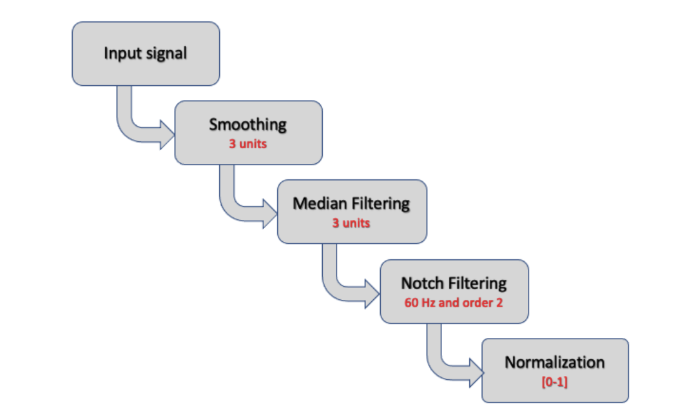

## Papers

1.  https://doi.org/10.1038/s41598-025-26476-1

2.   https://arxiv.org/abs/2502.07389

3.   https://doi.org/10.3390/bioengineering11010089


In [1]:
import os
import json
import numpy as np
import wfdb
import pywt
import matplotlib.pyplot as plt
from scipy.signal import medfilt, iirnotch, filtfilt, butter

# Visualize raw signal (30s and 5s window)

In [ ]:
record_name = '100'
data_dir = './mitdb'   

record = wfdb.rdrecord(os.path.join(data_dir, record_name))
fs = record.fs
signal = record.p_signal[:, record.sig_name.index('MLII')] if 'MLII' in record.sig_name else record.p_signal[:, 0]
lead_name = record.sig_name[record.sig_name.index('MLII')] if 'MLII' in record.sig_name else record.sig_name[0]

print(f"Record {record_name} | Lead: {lead_name} | Fs: {fs} Hz | Duration: {len(signal)/fs/60:.1f} min")

Record 100 | Lead: MLII | Fs: 360 Hz | Duration: 30.1 min


In [3]:
def plot_ecg_window(signal, fs, start_sec, duration_sec, title, color='black'):
    start_sample = int(start_sec * fs)
    end_sample = int((start_sec + duration_sec) * fs)
    segment = signal[start_sample:end_sample]
    t = np.arange(len(segment)) / fs + start_sec

    plt.figure(figsize=(14, 4))
    plt.plot(t, segment, linewidth=0.8, color=color)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

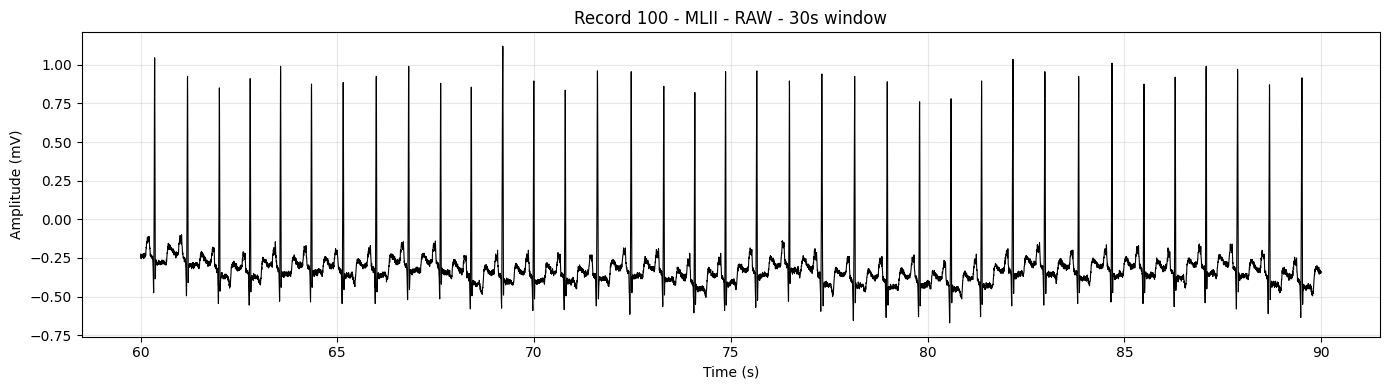

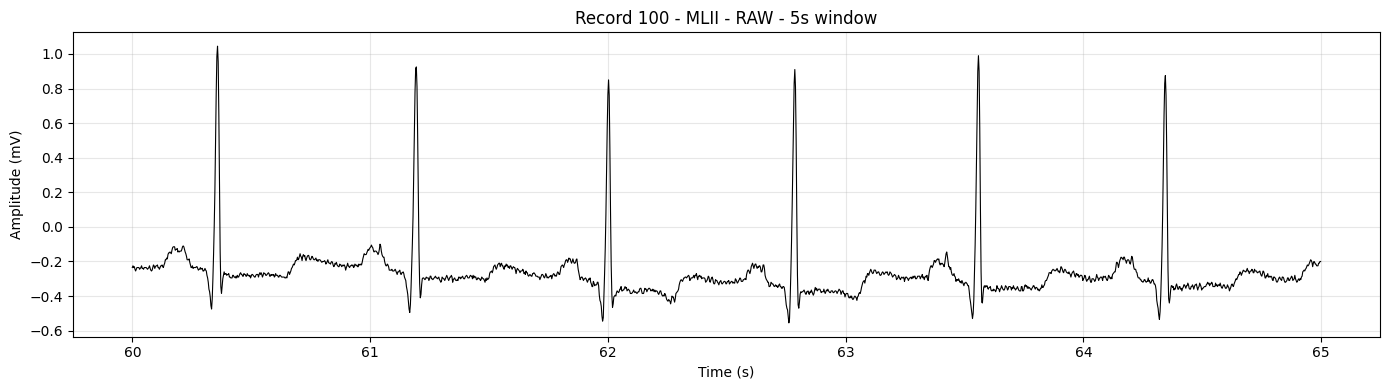

In [4]:
plot_ecg_window(signal, fs, start_sec=60, duration_sec=30,
                 title=f"Record {record_name} - {lead_name} - RAW - 30s window")

plot_ecg_window(signal, fs, start_sec=60, duration_sec=5,
                 title=f"Record {record_name} - {lead_name} - RAW - 5s window")

# Define all 4 pipelines

In [5]:
# ---------- Pipeline 1: SWT alone ----------
def swt_denoise(sig, wavelet='rbio3.9', level=5, threshold_scale=0.5):
    original_len = len(sig)
    pad_len = (2 ** level - original_len % 2 ** level) % 2 ** level
    sig_padded = np.pad(sig, (0, pad_len), mode='symmetric')
    coeffs = pywt.swt(sig_padded, wavelet, level=level)
    new_coeffs = []
    for cA, cD in coeffs:
        sigma = np.median(np.abs(cD)) / 0.6745
        thresh = threshold_scale * sigma * np.sqrt(2 * np.log(len(cD)))
        cD_thresh = pywt.threshold(cD, thresh, mode='soft')
        new_coeffs.append((cA, cD_thresh))
    denoised = pywt.iswt(new_coeffs, wavelet)
    return denoised[:original_len]


# ---------- Pipeline 2: Notch + SWT ----------
def notch_filter(sig, fs, freq=60, Q=26):
    b, a = iirnotch(freq, Q, fs)
    return filtfilt(b, a, sig)

def notch_plus_swt(sig, fs, notch_freq=60, wavelet='rbio3.9', level=5, threshold_scale=0.5):
    stage1 = notch_filter(sig, fs, freq=notch_freq)
    return swt_denoise(stage1, wavelet=wavelet, level=level, threshold_scale=threshold_scale)


# ---------- Pipeline 3: SMA -> Median -> Notch -> Normalize[0,1] ----------
def sma_smooth(sig, window=3):
    kernel = np.ones(window) / window
    return np.convolve(sig, kernel, mode='same')

def median_filter_stage(sig, window=3):
    return medfilt(sig, kernel_size=window)

def notch_filter_stage(sig, fs, freq=60, Q=30):
    b, a = iirnotch(freq, Q, fs)
    return filtfilt(b, a, sig)

def normalize_0_1(sig):
    return (sig - np.min(sig)) / (np.max(sig) - np.min(sig))

def sma_median_notch_pipeline(sig, fs, sma_window=3, median_window=3, notch_freq=60):
    stage1 = sma_smooth(sig, window=sma_window)
    stage2 = median_filter_stage(stage1, window=median_window)
    stage3 = notch_filter_stage(stage2, fs, freq=notch_freq)
    return normalize_0_1(stage3)


# ---------- Pipeline 4: Median -> Bandpass (FADE paper) ----------
def bandpass_filter_stage(sig, fs, lowcut=0.5, highcut=30, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, sig)

def median_bandpass_pipeline(sig, fs, median_window=3, lowcut=0.5, highcut=30):
    stage1 = median_filter_stage(sig, window=median_window)
    return bandpass_filter_stage(stage1, fs, lowcut=lowcut, highcut=highcut)


# ---------- Registry ----------
PIPELINES = {
    "swt": lambda sig, fs: swt_denoise(sig, wavelet='rbio3.9', level=5, threshold_scale=0.5),
    "notch_swt": lambda sig, fs: notch_plus_swt(sig, fs, notch_freq=60, wavelet='rbio3.9', level=5, threshold_scale=0.5),
    "sma_median_notch": lambda sig, fs: sma_median_notch_pipeline(sig, fs, sma_window=3, median_window=3, notch_freq=60),
    "median_bandpass": lambda sig, fs: median_bandpass_pipeline(sig, fs, median_window=3, lowcut=0.5, highcut=30),
}

# Visualize each pipeline on a single sample (5s)

In [6]:
results_single = {}
for name, func in PIPELINES.items():
    results_single[name] = func(signal, fs)
    print(f"{name} -> done, shape {results_single[name].shape}")

swt -> done, shape (650000,)
notch_swt -> done, shape (650000,)
sma_median_notch -> done, shape (650000,)
median_bandpass -> done, shape (650000,)


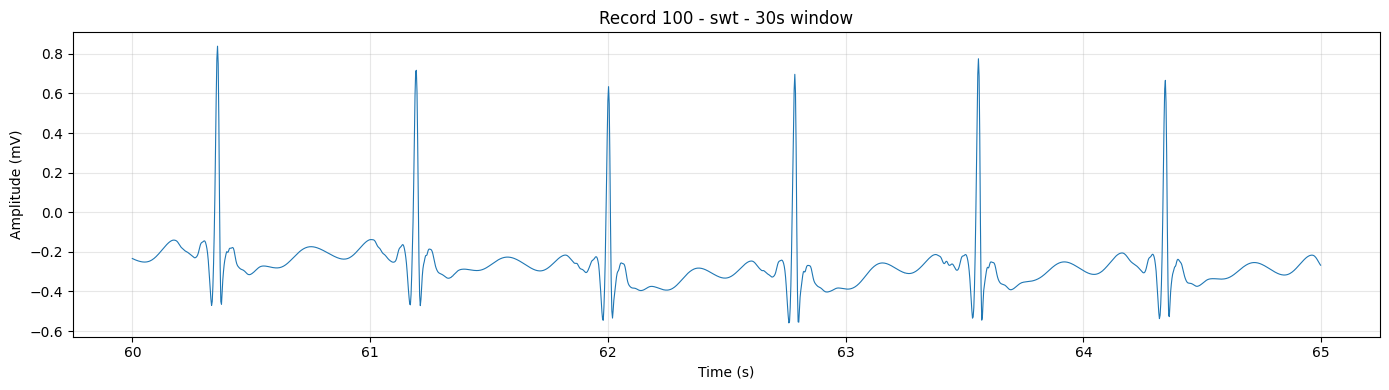

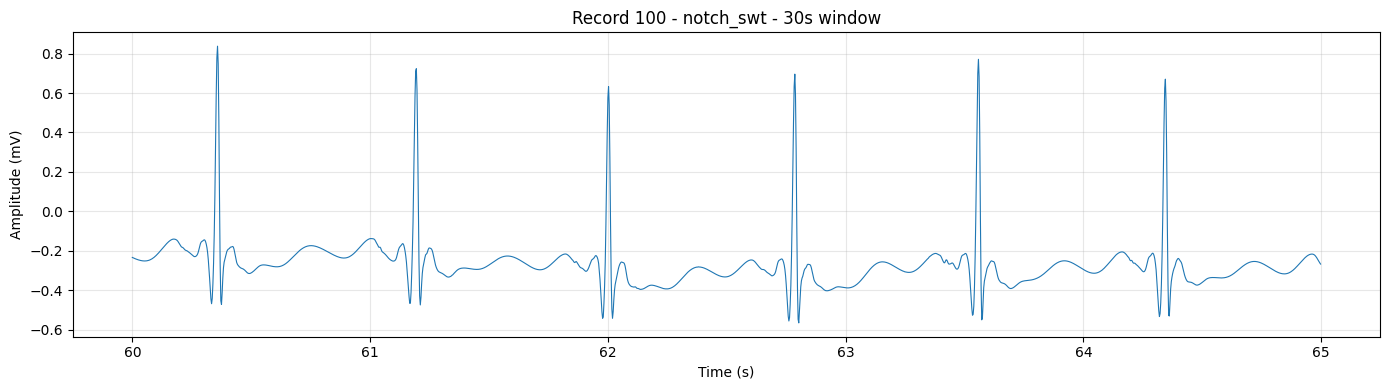

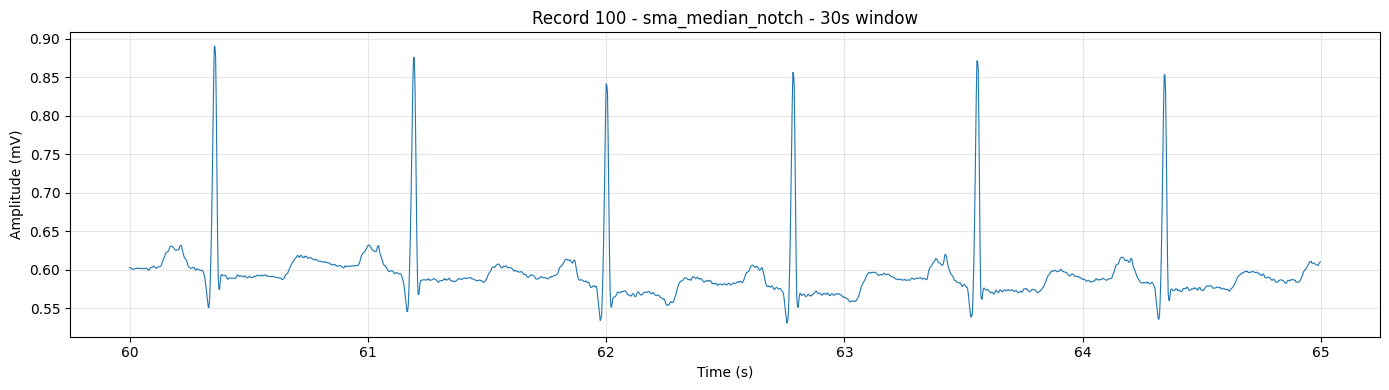

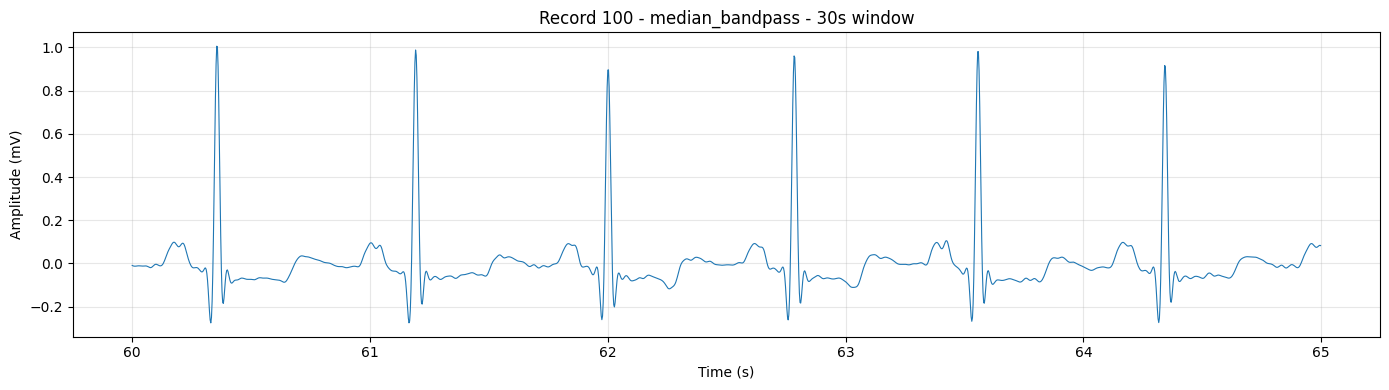

In [ ]:
for name, processed in results_single.items():
    plot_ecg_window(processed, fs, start_sec=60, duration_sec=5,
                     title=f"Record {record_name} - {name} - 5s window", color='tab:blue')

# processing all dataset

In [9]:
def find_records(data_dir):
    return sorted(f.split('.')[0] for f in os.listdir(data_dir) if f.endswith('.hea'))

def preprocess_folder(data_dir, pipeline_name, output_root="preprocessed",
                       preferred_lead="MLII"):
    pipeline_func = PIPELINES[pipeline_name]
    out_dir = os.path.join(output_root, pipeline_name)
    os.makedirs(out_dir, exist_ok=True)

    records = find_records(data_dir)
    print(f"Found {len(records)} records | Pipeline: {pipeline_name} | Output -> {out_dir}")

    failed = []
    for i, record_name in enumerate(records, 1):
        try:
            record = wfdb.rdrecord(os.path.join(data_dir, record_name))
            fs = record.fs
            ch_idx = record.sig_name.index(preferred_lead) if preferred_lead in record.sig_name else 0
            lead_name = record.sig_name[ch_idx]
            sig = record.p_signal[:, ch_idx]

            processed = pipeline_func(sig, fs)

            np.save(os.path.join(out_dir, f"{record_name}.npy"), processed.astype(np.float32))
            meta = {"record": record_name, "pipeline": pipeline_name, "fs": fs,
                    "lead_name": lead_name, "n_samples": len(processed)}
            with open(os.path.join(out_dir, f"{record_name}.json"), "w") as f:
                json.dump(meta, f, indent=2)

            print(f"[{i}/{len(records)}] {record_name} ({lead_name}) -> OK")
        except Exception as e:
            failed.append((record_name, str(e)))
            print(f"[{i}/{len(records)}] {record_name} -> FAILED: {e}")

    print(f"\nDone. {len(records)-len(failed)}/{len(records)} succeeded.")
    if failed:
        print("Failed:", failed)
    return failed

In [10]:
for pipeline_name in PIPELINES.keys():
    preprocess_folder(data_dir=data_dir, pipeline_name=pipeline_name, output_root="preprocessed")
    print("=" * 60)

Found 48 records | Pipeline: swt | Output -> preprocessed\swt
[1/48] 100 (MLII) -> OK
[2/48] 101 (MLII) -> OK
[3/48] 102 (V5) -> OK
[4/48] 103 (MLII) -> OK
[5/48] 104 (V5) -> OK
[6/48] 105 (MLII) -> OK
[7/48] 106 (MLII) -> OK
[8/48] 107 (MLII) -> OK
[9/48] 108 (MLII) -> OK
[10/48] 109 (MLII) -> OK
[11/48] 111 (MLII) -> OK
[12/48] 112 (MLII) -> OK
[13/48] 113 (MLII) -> OK
[14/48] 114 (MLII) -> OK
[15/48] 115 (MLII) -> OK
[16/48] 116 (MLII) -> OK
[17/48] 117 (MLII) -> OK
[18/48] 118 (MLII) -> OK
[19/48] 119 (MLII) -> OK
[20/48] 121 (MLII) -> OK
[21/48] 122 (MLII) -> OK
[22/48] 123 (MLII) -> OK
[23/48] 124 (MLII) -> OK
[24/48] 200 (MLII) -> OK
[25/48] 201 (MLII) -> OK
[26/48] 202 (MLII) -> OK
[27/48] 203 (MLII) -> OK
[28/48] 205 (MLII) -> OK
[29/48] 207 (MLII) -> OK
[30/48] 208 (MLII) -> OK
[31/48] 209 (MLII) -> OK
[32/48] 210 (MLII) -> OK
[33/48] 212 (MLII) -> OK
[34/48] 213 (MLII) -> OK
[35/48] 214 (MLII) -> OK
[36/48] 215 (MLII) -> OK
[37/48] 217 (MLII) -> OK
[38/48] 219 (MLII) -> OK
[

# Visualize a preprocessed sample

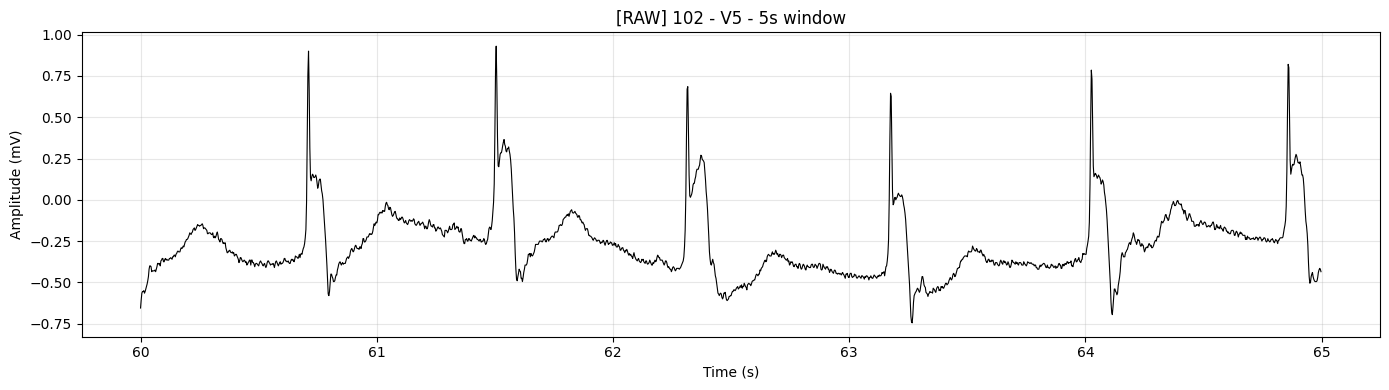

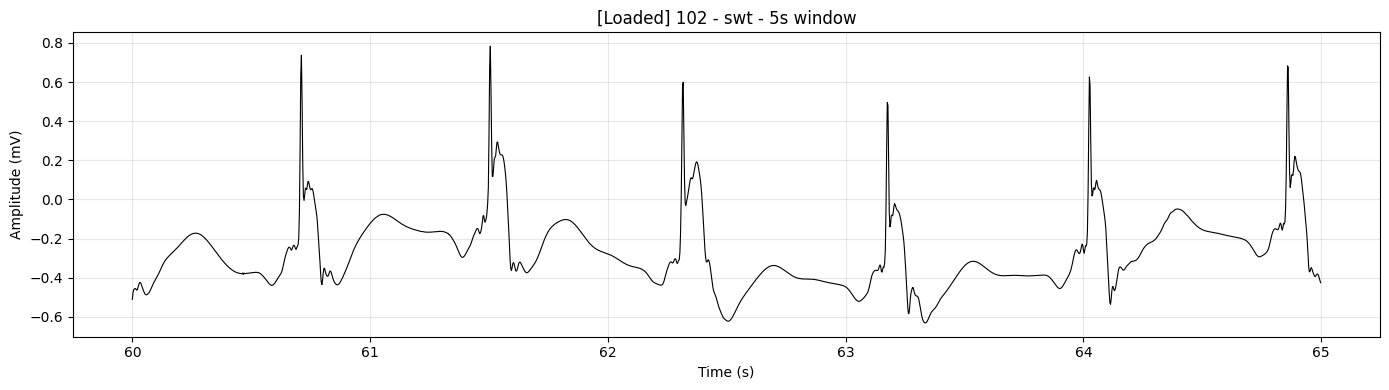

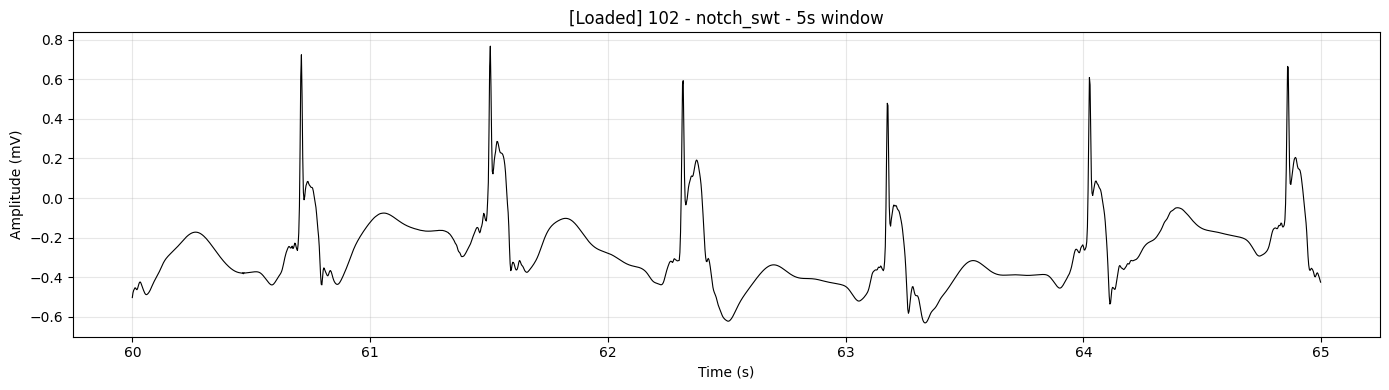

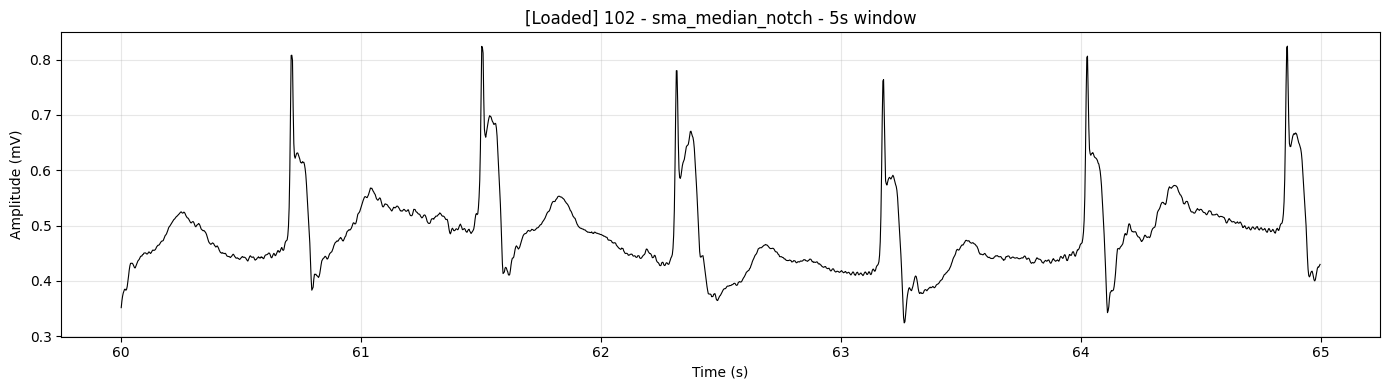

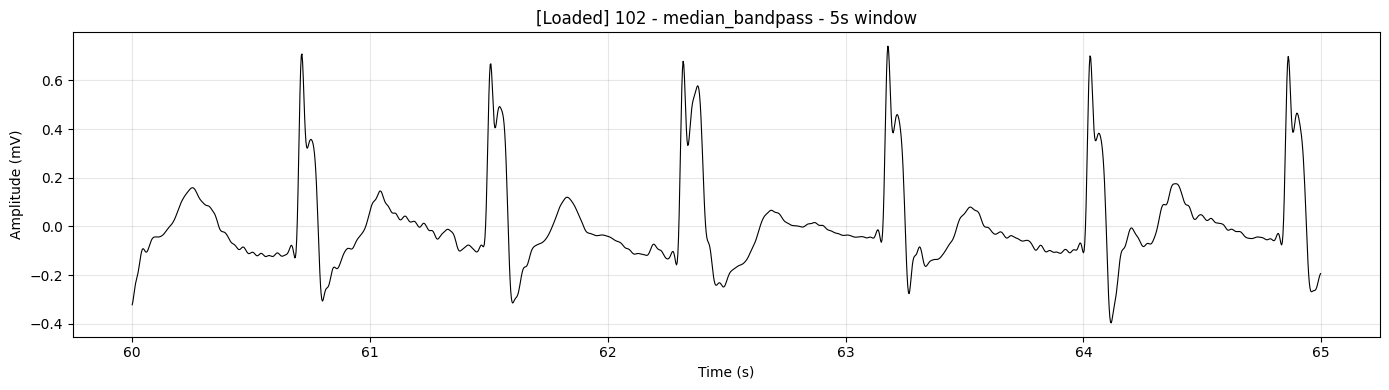

In [16]:
def load_preprocessed(pipeline_name, record_name, output_root="preprocessed"):
    npy_path = os.path.join(output_root, pipeline_name, f"{record_name}.npy")
    json_path = os.path.join(output_root, pipeline_name, f"{record_name}.json")
    signal_loaded = np.load(npy_path)
    with open(json_path) as f:
        meta = json.load(f)
    return signal_loaded, meta
record_102 = wfdb.rdrecord(os.path.join(data_dir, '102'))
fs_102 = record_102.fs
ch_idx_102 = record_102.sig_name.index('MLII') if 'MLII' in record_102.sig_name else 0
lead_name_102 = record_102.sig_name[ch_idx_102]
signal_102_raw = record_102.p_signal[:, ch_idx_102]

# Plot raw BEFORE preprocessing
plot_ecg_window(signal_102_raw, fs_102, start_sec=60, duration_sec=5,
                 title=f"[RAW] 102 - {lead_name_102} - 5s window")

for pipeline_name in PIPELINES.keys():
    sig_loaded, meta = load_preprocessed(pipeline_name, 102)
    plot_ecg_window(sig_loaded, meta["fs"], start_sec=60, duration_sec=5,
                     title=f"[Loaded] {102} - {pipeline_name} - 5s window")

## Future Work (Weekend) => Continuing the Preprocessing Pipeline

- **Normalization strategy**
  Compare how each paper normalizes signals (z-score, min-max [0,1], empirical clamping + range normalization) and decide which fits our forecasting task best. Some papers avoid normalization when the data contains abnormalities (to preserve the raw abnormal characteristics), while others do normalize. I need to spend more time researching this to decide the right approach for our case.

- **Train/test split strategy**

- **How to compare pipelines against a baseline**
  to compare preprocessing pipelines using baseline forecasting models.

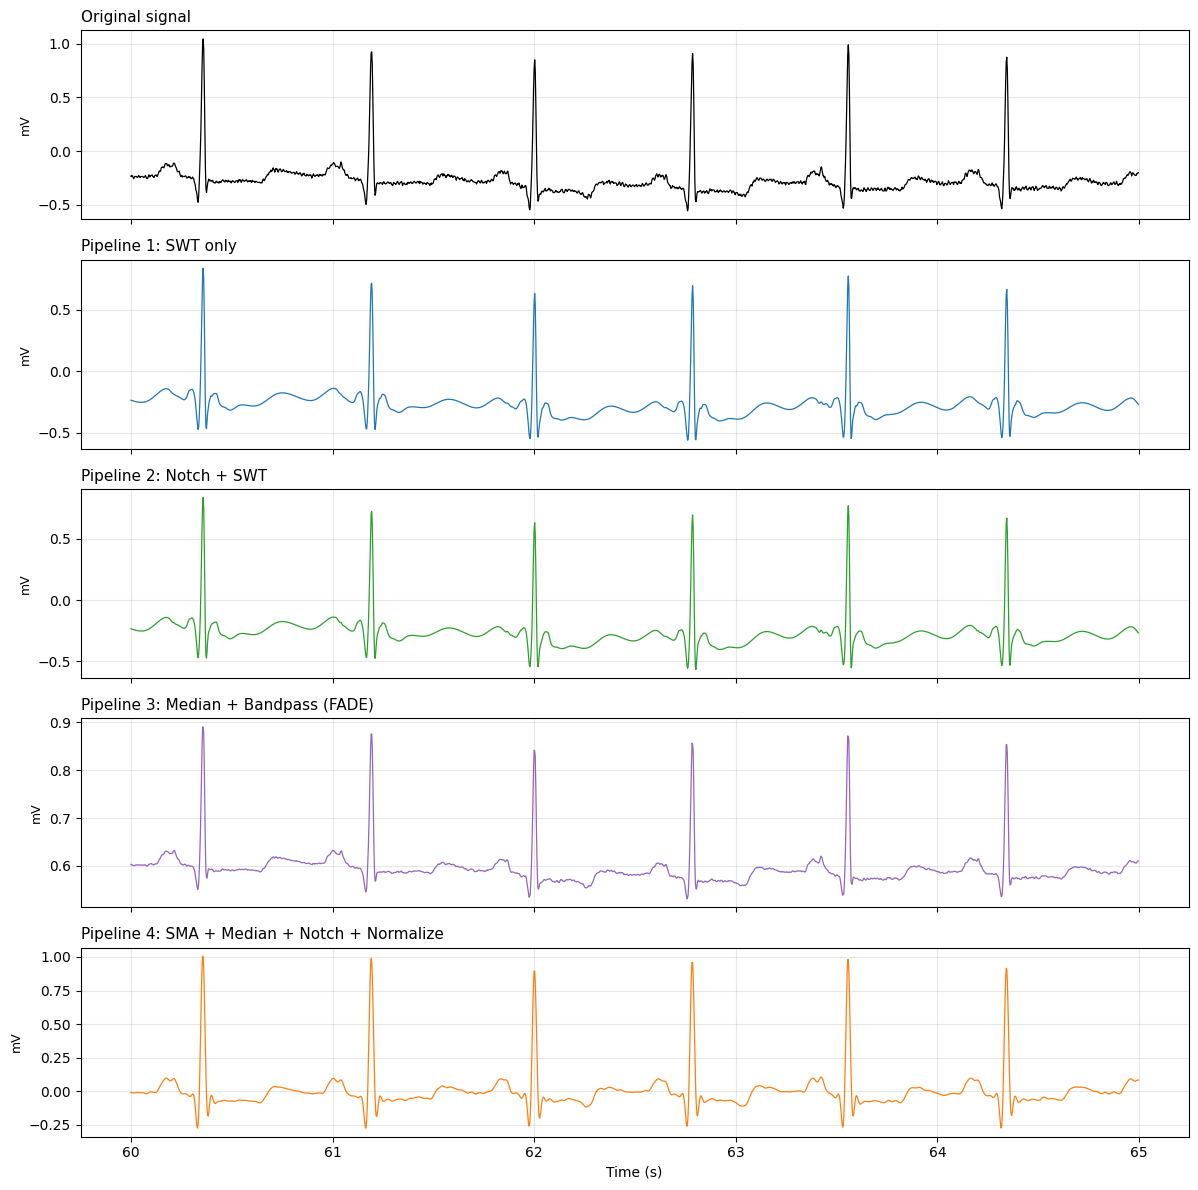

In [17]:
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

start_sec = 60
duration_sec = 5
start_sample = int(start_sec * fs)
end_sample = int((start_sec + duration_sec) * fs)
t = np.arange(end_sample - start_sample) / fs + start_sec

# Original
axes[0].plot(t, signal[start_sample:end_sample], color='black', linewidth=0.9)
axes[0].set_title("Original signal", fontsize=11, loc='left')
axes[0].set_ylabel("mV", fontsize=9)

# Each pipeline
colors = ['tab:blue', 'tab:green', 'tab:purple', 'tab:orange']
titles = ["Pipeline 1: SWT only", "Pipeline 2: Notch + SWT",
          "Pipeline 3: Median + Bandpass (FADE)", "Pipeline 4: SMA + Median + Notch + Normalize"]

for ax, (name, func), color, title in zip(axes[1:], PIPELINES.items(), colors, titles):
    processed = func(signal, fs)
    ax.plot(t, processed[start_sample:end_sample], color=color, linewidth=0.9)
    ax.set_title(title, fontsize=11, loc='left')
    ax.set_ylabel("mV", fontsize=9)

axes[-1].set_xlabel("Time (s)", fontsize=10)

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pipeline_comparison.png", dpi=300, bbox_inches='tight')
plt.show()